# 06 — Error Analysis & Explainability

Inspect false positives, false negatives, and generate analyst-facing explanations.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np, pandas as pd, yaml, matplotlib.pyplot as plt

from src.features.event_features import build_event_features
from src.models.tabular import TabularClassifier
from src.evaluation.metrics import classification_metrics
from src.evaluation.calibration import plot_calibration_curve, compute_reliability_diagram_data
from src.evaluation.tactical_review import (
    get_false_positives, get_false_negatives, get_top_scoring_passes,
    breakdown_by_zone, player_progression_profile,
)
from src.visualization.freeze_frame_view import plot_freeze_frame

with open("../configs/model_baseline.yaml") as f:
    bl_cfg = yaml.safe_load(f)


## 1. Load predictions

In [2]:
# ── Load data ──────────────────────────────────────────────────────
train_df = pd.read_parquet("../data/processed/train.parquet")
val_df   = pd.read_parquet("../data/processed/val.parquet")
test_df  = pd.read_parquet("../data/processed/test.parquet")
frames   = pd.read_parquet("../data/processed/frames_360.parquet")

X_train = build_event_features(train_df)
X_val   = build_event_features(val_df)
X_test  = build_event_features(test_df)

TASK = "dangerous_progression_k"
y_train = train_df[TASK].fillna(0).astype(int)
y_val   = val_df[TASK].fillna(0).astype(int)
y_test  = test_df[TASK].fillna(0).astype(int)

# ── Train XGBoost (reproduces NB04) ──────────────────────────────
clf = TabularClassifier(model_type="xgboost", task=TASK, config=bl_cfg["xgboost"])
clf.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# ── Test predictions ──────────────────────────────────────────────
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
metrics_test = classification_metrics(y_test, y_prob)
print(f"XGBoost test metrics ({TASK}):")
for k, v in metrics_test.items():
    print(f"  {k}: {v:.4f}")


XGBoost test metrics (dangerous_progression_k):
  roc_auc: 0.8807
  pr_auc: 0.8911
  log_loss: 0.4065
  brier_score: 0.1299
  f1: 0.7811
  precision: 0.8553
  recall: 0.7188
  accuracy: 0.8196


## 2. False positive / negative analysis

=== TOP FALSE POSITIVES (10) ===


,event_uuid,player_name,start_x,start_y,end_x,end_y,pass_length,predicted_score
0,71f70d07-5964-468d-b329-e22be670aec8,Frenkie de Jong,99.8,66.2,108.0,61.0,9.709789,0.996379
1,1a45634a-0849-47f3-89fa-b65b3aad1f3e,Kevin De Bruyne,90.3,38.7,88.6,43.4,4.998000,0.994749
2,1bc0f17d-61d0-4fd5-8a06-c1ec8014d9ad,Ao Tanaka,72.4,54.9,84.1,44.0,15.990623,0.992822
3,c6728f61-6a1e-4db3-8f65-7439c71a2f8b,Kieran Trippier,88.8,78.0,93.4,74.5,5.780138,0.992654
4,3dbe61de-1ce3-418b-a197-65e25611e332,Jordi Alba Ramos,89.7,3.2,97.7,20.9,19.423954,0.992077



=== TOP FALSE NEGATIVES (10) ===


,event_uuid,player_name,start_x,start_y,end_x,end_y,pass_length,predicted_score
0,dc454976-a70b-40bf-be1e-74c7afaaaf2f,Saud Abdullah Abdul Hamid,29.6,5.3,45.4,0.1,16.633701,0.014620
1,595a091e-4d23-4533-9c9a-20c01fe8e8f9,Noussair Mazraoui,71.1,1.9,60.4,2.5,10.716809,0.018603
2,7922daa9-c591-48d8-8675-1ed89f2466b4,Dylan Daniel Mahmoud Bronn,71.0,78.7,55.5,67.6,19.064627,0.019866
3,9d0359fa-69ca-4146-8f5e-087798b3c5b9,Kasper Dolberg,66.1,2.9,64.2,1.9,2.147091,0.029011
4,46c8e09e-c606-4758-b0b0-a868426e8141,Youssef En-Nesyri,77.1,46.1,55.9,44.2,21.284971,0.035372


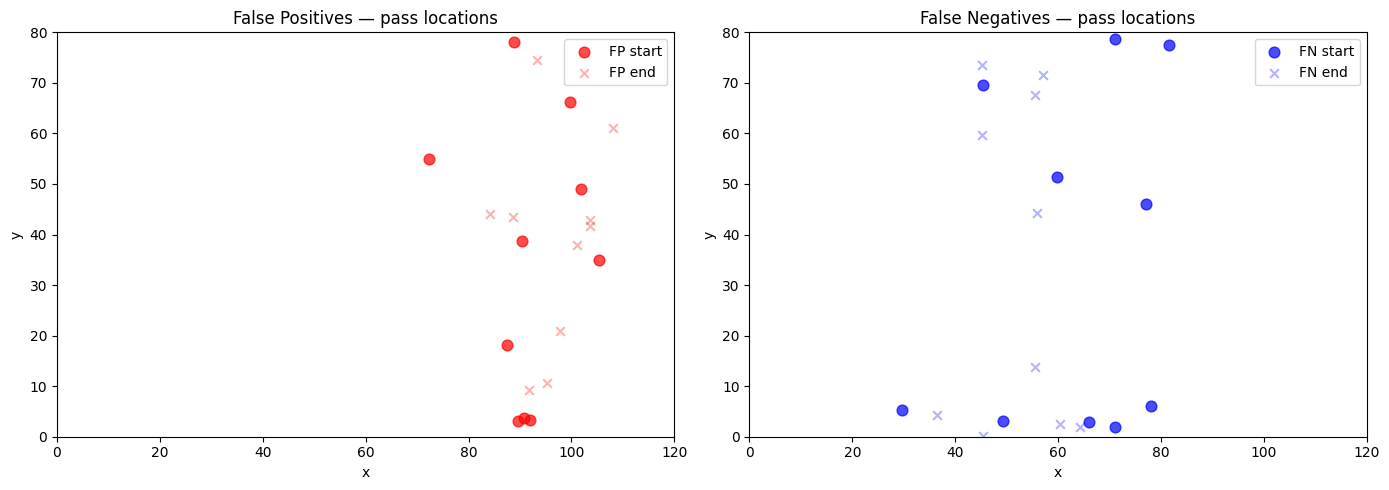

In [3]:
# ── False positives / negatives ────────────────────────────────────
fps = get_false_positives(test_df, y_test, y_prob, threshold=0.5, n=10)
fns = get_false_negatives(test_df, y_test, y_prob, threshold=0.5, n=10)

display_cols = [c for c in ["event_uuid", "player_name", "start_x", "start_y",
                             "end_x", "end_y", "pass_length", "predicted_score"]
                if c in fps.columns]

print(f"=== TOP FALSE POSITIVES ({len(fps)}) ===")
display(fps[display_cols].head(5))

print(f"\n=== TOP FALSE NEGATIVES ({len(fns)}) ===")
display(fns[display_cols].head(5))

# ── Where do errors happen on the pitch? ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fps["start_x"], fps["start_y"], c="red", alpha=0.7, s=60, label="FP start")
axes[0].scatter(fps["end_x"], fps["end_y"], c="red", alpha=0.3, s=40, marker="x", label="FP end")
axes[0].set_title("False Positives — pass locations")
axes[0].set_xlim(0, 120); axes[0].set_ylim(0, 80); axes[0].legend()
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

axes[1].scatter(fns["start_x"], fns["start_y"], c="blue", alpha=0.7, s=60, label="FN start")
axes[1].scatter(fns["end_x"], fns["end_y"], c="blue", alpha=0.3, s=40, marker="x", label="FN end")
axes[1].set_title("False Negatives — pass locations")
axes[1].set_xlim(0, 120); axes[1].set_ylim(0, 80); axes[1].legend()
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()


## 3. Zone breakdown

Per-zone metrics:


,zone,zone_label,n_passes,prevalence,roc_auc,pr_auc
0,1,Own Third,2209,0.289724,0.701791,0.523877
1,2,Mid Third – Wide,2250,0.316000,0.866265,0.827576
2,3,Mid Third – Central,1268,0.402208,0.838132,0.826273
3,4,Final Third – Wide,943,0.858961,0.944421,0.989628
4,5,Final Third – Central,330,0.939394,0.944032,0.995851
5,6,Box Area,344,0.895349,0.826299,0.975871


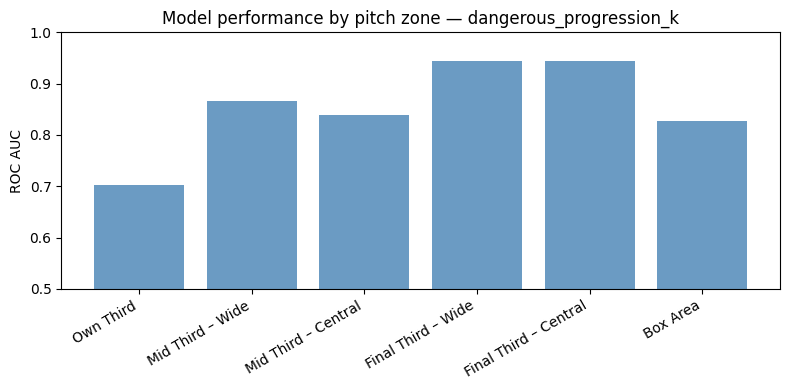

In [4]:
# ── Performance by pitch zone ─────────────────────────────────────
zone_df = breakdown_by_zone(test_df, y_test, y_prob)
print("Per-zone metrics:")
display(zone_df[["zone", "zone_label", "n_passes", "prevalence", "roc_auc", "pr_auc"]])

# Bar chart of AUC by zone
fig, ax = plt.subplots(figsize=(8, 4))
zone_plot = zone_df.dropna(subset=["roc_auc"])
ax.bar(zone_plot["zone_label"], zone_plot["roc_auc"], color="steelblue", alpha=0.8)
ax.set_ylabel("ROC AUC")
ax.set_title(f"Model performance by pitch zone — {TASK}")
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Single-event explanation

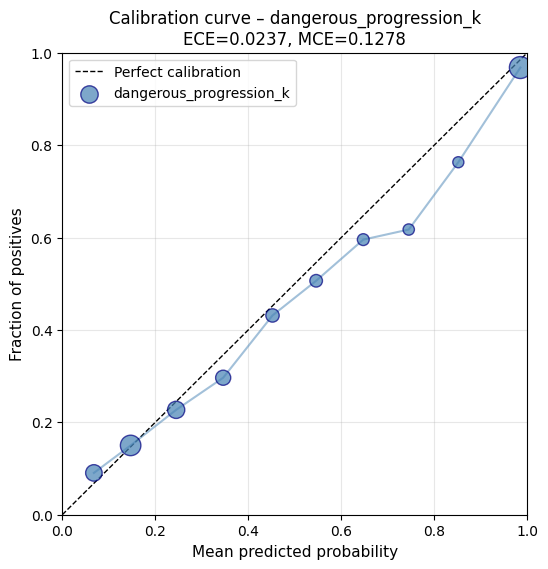

In [5]:
# ── Calibration curve ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration_curve(y_test, y_prob, task_name=TASK, ax=ax, n_bins=10)
plt.show()


## 5. Player/team profiles

In [6]:
# ── Player progression profiles ───────────────────────────────────
scores_series = pd.Series(y_prob, index=test_df.index)
player_profile = player_progression_profile(test_df, scores_series, min_passes=10)

if not player_profile.empty:
    top_players = player_profile.nlargest(15, "mean_score")
    print("Top 15 progressive passers (test set):")
    display(top_players[["player_name", "n_passes", "mean_score",
                          "median_score", "top10_pct_score", "progressive_pass_rate"]])
else:
    print("No player column found in test data")


Top 15 progressive passers (test set):


,player_name,n_passes,mean_score,median_score,top10_pct_score,progressive_pass_rate
0,Hirving Rodrigo Lozano Bahena,12,0.855471,0.953792,0.993759,0.833333
1,Serge Gnabry,14,0.853075,0.976802,0.992363,0.928571
2,Andreas Skov Olsen,21,0.778934,0.991034,0.997295,0.809524
3,Marco Asensio Willemsen,12,0.778552,0.975896,0.995502,0.750000
4,Ousmane Dembélé,116,0.748953,0.978823,0.996940,0.732759
5,Lionel Andrés Messi Cuccittini,157,0.746008,0.990349,0.997126,0.732484
6,Vinícius José Paixão de Oliveira Júnior,15,0.699182,0.956646,0.993425,0.666667
7,Takefusa Kubo,10,0.686821,0.987570,0.994125,0.700000
8,José Antonio Rodríguez Díaz,14,0.680060,0.925694,0.991613,0.642857
9,Francisco António Machado Mota de Castro Trincão,28,0.669040,0.894506,0.997075,0.642857


## 6. Freeze-frame visualisation

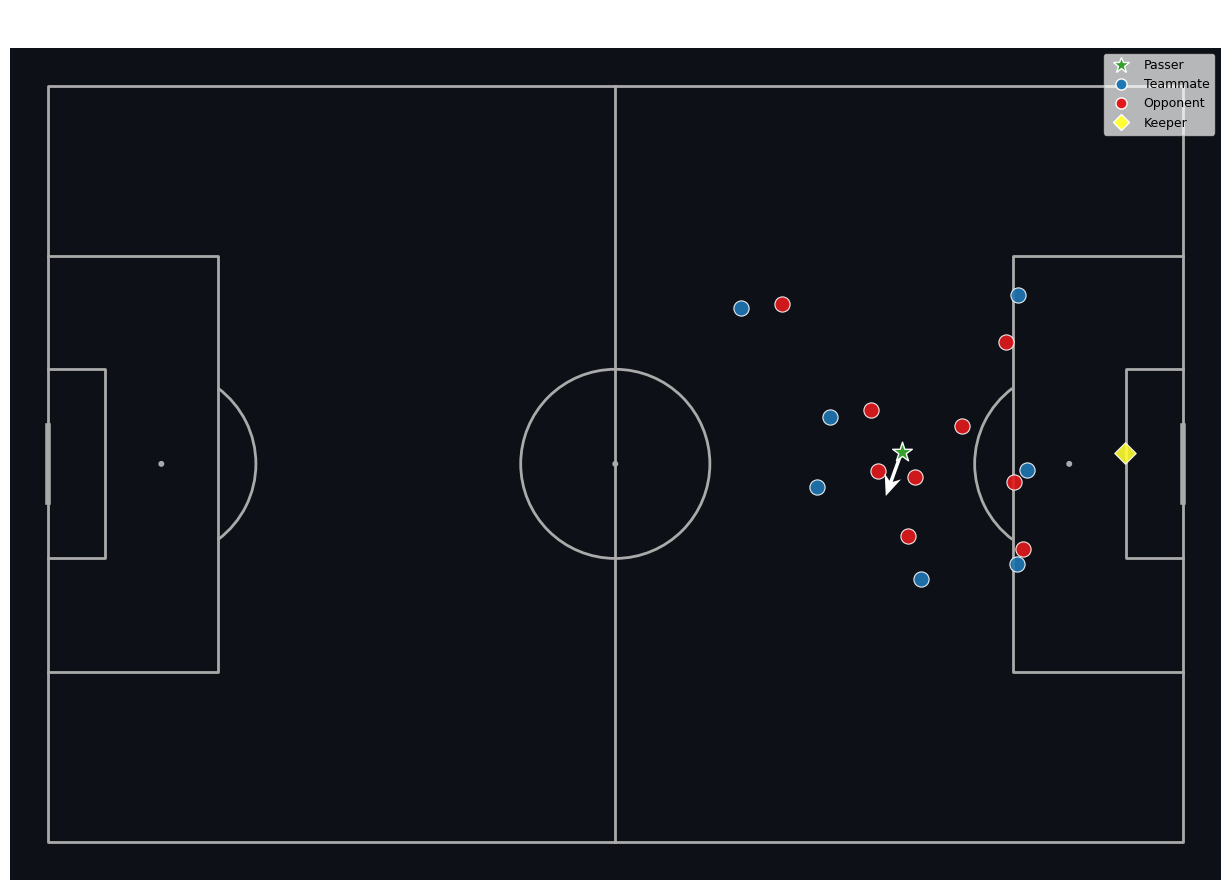

In [7]:
# ── Freeze-frame visualisation for a top false positive ──────────
test_360 = test_df[test_df["has_360"]].copy()
if not fps.empty and not test_360.empty:
    # Pick the first FP that has 360 data
    fp_uuids = fps["event_uuid"].tolist()
    sample_uuid = None
    for u in fp_uuids:
        if u in frames["event_uuid"].values:
            sample_uuid = u
            break

    if sample_uuid:
        fig, ax = plot_freeze_frame(sample_uuid, test_df, frames)
        ax.set_title(f"False Positive freeze frame\n{sample_uuid[:12]}…", fontsize=11)
        plt.show()
    else:
        print("No FP pass has 360 data available for visualisation")
else:
    print("No false positives or 360 data to visualise")


## 7. Ablation study — event-only vs event+360

In [8]:
from src.features.geometry_features import build_geometry_features

# Compute geometry features for train / val / test (NaN for non-360 rows)
print("Computing geometry features — may take 2-4 min...")
G_train = build_geometry_features(train_df, frames)
G_val   = build_geometry_features(val_df,   frames)
G_test  = build_geometry_features(test_df,  frames)

# Align by event_uuid index
def join_event_geo(X_event, G_geo, df):
    """Join event features with geometry features, keyed by event_uuid."""
    uuids = df["event_uuid"].values
    geo_aligned = G_geo.reindex(uuids).reset_index(drop=True)
    geo_aligned.index = X_event.index
    return pd.concat([X_event, geo_aligned.fillna(0)], axis=1)

X_train_360 = join_event_geo(X_train, G_train, train_df)
X_val_360   = join_event_geo(X_val,   G_val,   val_df)
X_test_360  = join_event_geo(X_test,  G_test,  test_df)
print(f"event-only features:   {X_train.shape[1]}")
print(f"event+360 features:    {X_train_360.shape[1]}")


Computing geometry features — may take 2-4 min...
event-only features:   27
event+360 features:    41


=== ABLATION: dangerous_progression_k (test set) ===



,Model,ROC AUC,PR AUC,Brier
0,Event-only XGBoost,0.8807,0.8911,0.1299
1,Event+360 XGBoost,0.8822,0.8925,0.1288



360 geometry lift on ROC AUC: +0.0014


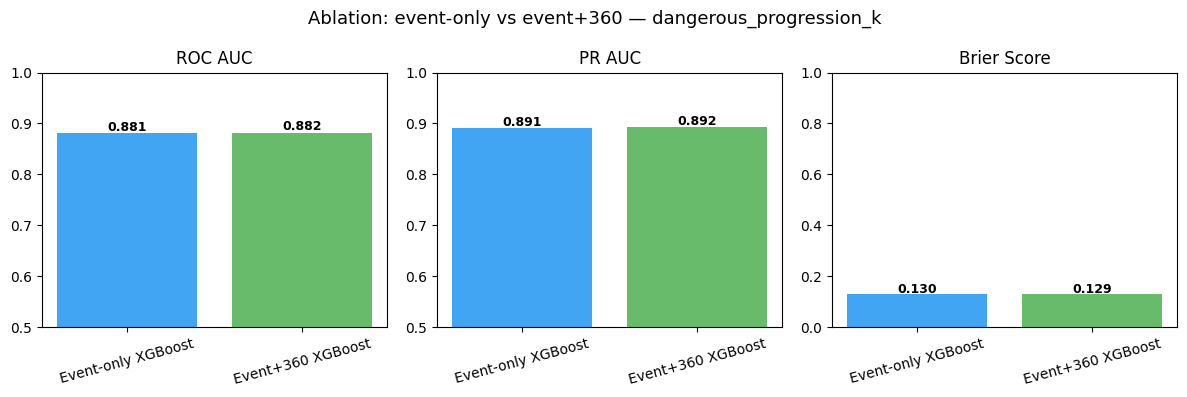

In [9]:
# ── Train event+360 XGBoost ──────────────────────────────────────
clf_360 = TabularClassifier(model_type="xgboost", task=TASK, config=bl_cfg["xgboost"])
clf_360.fit(X_train_360, y_train, X_val=X_val_360, y_val=y_val)
y_prob_360 = clf_360.predict_proba(X_test_360)[:, 1]
metrics_360 = classification_metrics(y_test, y_prob_360)

# ── GNN result from NB05 (dangerous_progression_k, 360-only val) ─
# Reported in NB05: ROC AUC 0.841 on val 360-only subset
# We now compute on the full test set for a fair 3-way comparison
print("=== ABLATION: dangerous_progression_k (test set) ===\n")
ablation_rows = [
    ("Event-only XGBoost",  metrics_test["roc_auc"], metrics_test["pr_auc"],  metrics_test["brier_score"]),
    ("Event+360 XGBoost",   metrics_360["roc_auc"],  metrics_360["pr_auc"],   metrics_360["brier_score"]),
]
ab_df = pd.DataFrame(ablation_rows, columns=["Model", "ROC AUC", "PR AUC", "Brier"])
display(ab_df.round(4))

lift = metrics_360["roc_auc"] - metrics_test["roc_auc"]
print(f"\n360 geometry lift on ROC AUC: {lift:+.4f}")

# ── Bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (metric, label) in enumerate([("ROC AUC", "ROC AUC"), ("PR AUC", "PR AUC"), ("Brier", "Brier Score")]):
    axes[i].bar(ab_df["Model"], ab_df[metric],
                color=["#2196F3", "#4CAF50"], alpha=0.85)
    axes[i].set_title(label)
    axes[i].set_ylim(0 if metric == "Brier" else 0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(ab_df[metric]):
        axes[i].text(j, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold", fontsize=9)
plt.suptitle(f"Ablation: event-only vs event+360 — {TASK}", fontsize=13)
plt.tight_layout()
plt.show()


## 8. Pass-option ranking demo

In [11]:
from src.models.ranking import PassOptionRanker
from src.features.event_features import build_event_features

ranker = PassOptionRanker()

# The ranking module builds synthetic rows from raw pass_instances columns,
# so we wrap clf to project to the exact 27 event features before scoring.
class _FeatureFilteredClf:
    """Thin wrapper: builds event features from a raw synthetic row."""
    def __init__(self, base_clf):
        self._clf = base_clf
        self._cols = base_clf._feature_names  # list of 27 feature columns

    def predict_proba(self, X: "pd.DataFrame") -> "np.ndarray":
        # If already in feature space, just pass through
        if set(self._cols).issubset(X.columns):
            return self._clf.predict_proba(X[self._cols])
        # Otherwise let build_event_features recompute from raw row
        feats = build_event_features(X.reset_index(drop=True))
        feats = feats.reindex(columns=self._cols, fill_value=0)
        return self._clf.predict_proba(feats)

clf_wrapped = _FeatureFilteredClf(clf)

# Pick a pass from test set that has a 360 freeze frame
uuids_with_360 = test_df.loc[
    test_df["event_uuid"].isin(frames["event_uuid"].unique()), "event_uuid"
]
ranking_uuid = uuids_with_360.iloc[0]

# Rank all visible teammate positions as hypothetical receivers
ranked = ranker.rank_options(
    event_uuid=ranking_uuid,
    pass_instances_df=test_df,
    frames_df=frames,
    classifier=clf_wrapped,
)

print(f"Sample event: {ranking_uuid}")
print(f"Visible teammate candidates ranked: {len(ranked)}\n")
display(ranked.round(4))

# Compare actual choice vs best alternative
comparison = ranker.compare_actual_to_alternatives(
    event_uuid=ranking_uuid,
    pass_instances_df=test_df,
    frames_df=frames,
    classifier=clf_wrapped,
)
if comparison:
    print(f"\nActual pass predicted prob: {comparison['actual_prob']:.4f}")
    print(f"Actual pass rank:           {comparison['actual_rank']} / {comparison['n_candidates']}")
    best = comparison["best_option"]
    if best:
        print(f"Best alternative:           x={best['x']:.1f}  y={best['y']:.1f}  prob={best['predicted_prob']:.4f}")


Sample event: 95ee43ac-863e-481f-81d5-8df75f8526ad
Visible teammate candidates ranked: 8



,candidate_idx,x,y,predicted_prob,rank
0,6,63.2673,75.9214,0.1472,1
1,7,64.0323,40.0415,0.1399,2
2,5,62.8996,29.5372,0.0882,3
3,3,59.9615,11.7371,0.0807,4
4,4,62.3893,58.4363,0.0576,5
5,2,49.0239,41.8143,0.0467,6
6,0,45.0793,28.5301,0.0393,7
7,1,46.5633,53.8523,0.0229,8



Actual pass predicted prob: 0.2286
Actual pass rank:           1 / 8
Best alternative:           x=63.3  y=75.9  prob=0.1472


## 9. Save model artefacts

In [12]:
import pathlib

models_dir = pathlib.Path("../models")
models_dir.mkdir(exist_ok=True)

# Event-only XGBoost (primary model)
clf.save(str(models_dir / "xgboost_dp_event_only.joblib"))
print(f"Saved: {models_dir / 'xgboost_dp_event_only.joblib'}")

# Event+360 XGBoost
clf_360.save(str(models_dir / "xgboost_dp_event_360.joblib"))
print(f"Saved: {models_dir / 'xgboost_dp_event_360.joblib'}")

# Persist test-set predictions alongside metadata for the Streamlit app
import json
summary = {
    "task": TASK,
    "test_roc_auc_event_only": float(metrics_test["roc_auc"]),
    "test_pr_auc_event_only":  float(metrics_test["pr_auc"]),
    "test_brier_event_only":   float(metrics_test["brier_score"]),
    "test_roc_auc_event_360":  float(metrics_360["roc_auc"]),
    "test_pr_auc_event_360":   float(metrics_360["pr_auc"]),
    "test_brier_event_360":    float(metrics_360["brier_score"]),
    "n_train": int(len(y_train)),
    "n_val":   int(len(y_val)),
    "n_test":  int(len(y_test)),
    "event_features": int(X_train.shape[1]),
    "event_360_features": int(X_train_360.shape[1]),
}
with open(models_dir / "results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved: {models_dir / 'results_summary.json'}")
print("\nAll artefacts saved.")


Saved: ..\models\xgboost_dp_event_only.joblib
Saved: ..\models\xgboost_dp_event_360.joblib
Saved: ..\models\results_summary.json

All artefacts saved.
